# SHAP — Interprétabilité du Modèle Final
### Analyse de l'impact de chaque variable sur les prédictions
---

## 0. Imports

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

root_dir = Path.cwd().parent

print(f'SHAP version : {shap.__version__}')
print('Imports OK ✅')

SHAP version : 0.51.0
Imports OK ✅


## 1. Chargement du modèle final et des données

In [25]:
# Chargement des données
X_train = np.load(root_dir / 'pipeline' / 'X_train.npy')
X_test  = np.load(root_dir / 'pipeline' / 'X_test.npy')
y_test  = np.load(root_dir / 'pipeline' / 'y_test.npy')

with open(root_dir / 'pipeline' / 'feature_names.json') as f:
    feature_names = json.load(f)

# Chargement du modèle final
# ⚠️ Remplace par le modèle que tu as sélectionné
best_model = joblib.load(root_dir / 'models' / 'best_model.pkl')

print(f'Features : {feature_names}')
print(f'X_train  : {X_train.shape}')
print(f'X_test   : {X_test.shape}')
print(f'Modèle   : {type(best_model).__name__}')

Features : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']
X_train  : (3657, 7)
X_test   : (915, 7)
Modèle   : XGBRegressor


## 2. Création de l'explainer SHAP

### Pourquoi SHAP ?
SHAP (SHapley Additive exPlanations) explique **pourquoi** le modèle fait une prédiction précise.
Contrairement à la feature importance classique (vision globale uniquement),
SHAP donne :
- Une vision **globale** : quelles variables influencent le modèle en général ?
- Une vision **locale** : pourquoi CETTE prédiction précise a-t-elle cette valeur ?

Pour un CMO : "Pourquoi cette campagne avec 80M€ TV + influenceur Mega prédit 310M€ de ventes ?"

In [26]:
# TreeExplainer : optimisé pour les modèles basés sur les arbres
# (Random Forest, XGBoost, GradientBoosting)
# Si ton modèle final est le MLP ou Ridge → utilise shap.KernelExplainer

model_name = type(best_model).__name__
tree_models = ['XGBRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor']

if model_name in tree_models:
    print(f'Utilisation de TreeExplainer pour {model_name}')
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
else:
    print(f'Utilisation de KernelExplainer pour {model_name}')
    # KernelExplainer plus lent — on utilise un échantillon de 200 obs
    background = shap.sample(X_train, 100)
    explainer = shap.KernelExplainer(best_model.predict, background)
    shap_values = explainer.shap_values(X_test[:200])
    X_test = X_test[:200]  # aligner pour les plots

print(f'SHAP values calculées ✅')
print(f'Shape SHAP values : {shap_values.shape}')

Utilisation de TreeExplainer pour XGBRegressor
SHAP values calculées ✅
Shape SHAP values : (915, 7)


## 3. Importance globale — Beeswarm Plot

Montre **quelles variables influencent le plus le modèle** et dans quel sens.
- Axe X : valeur SHAP (impact sur la prédiction)
- Couleur : valeur de la feature (rouge = élevé, bleu = faible)
- Chaque point = une observation

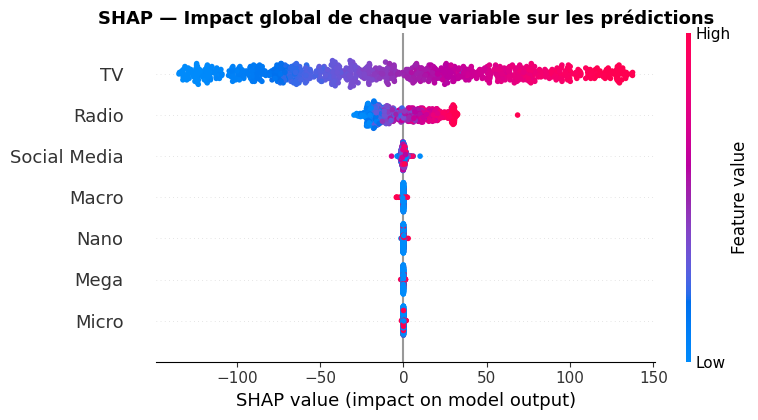

Sauvegardé → shap_beeswarm.png ✅


In [27]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP — Impact global de chaque variable sur les prédictions', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'shap_output' / 'shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()
print('Sauvegardé → shap_beeswarm.png ✅')

## 4. Importance globale — Bar Plot

Version simplifiée : importance moyenne absolue des SHAP values.
Plus lisible pour un utilisateur métier (CMO).

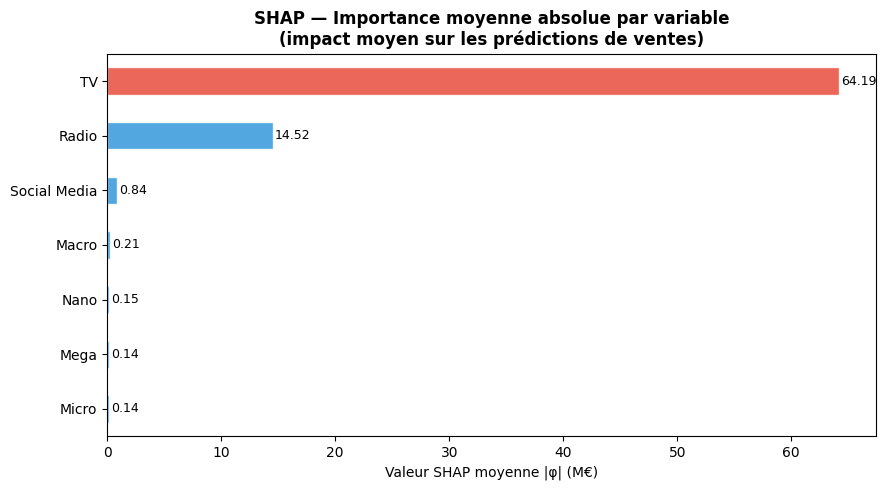


=== Importance SHAP par variable ===
TV              64.193649
Radio           14.517039
Social Media     0.840379
Macro            0.207638
Nano             0.152222
Mega             0.139090
Micro            0.137594

Sauvegardé → shap_importance_bar.png ✅


In [28]:
# Calcul de l'importance moyenne absolue
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=feature_names)\
                    .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v == shap_importance.max() else '#3498db' 
          for v in shap_importance.values]
shap_importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
ax.set_title('SHAP — Importance moyenne absolue par variable\n(impact moyen sur les prédictions de ventes)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Valeur SHAP moyenne |φ| (M€)')

# Annotations
for i, (val, name) in enumerate(zip(shap_importance.values, shap_importance.index)):
    ax.text(val + 0.2, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(root_dir / 'shap_output' / 'shap_importance_bar.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== Importance SHAP par variable ===')
print(shap_importance.sort_values(ascending=False).to_string())
print('\nSauvegardé → shap_importance_bar.png ✅')

## 5. SHAP Dependence Plot — Impact marginal visuel

Montre comment la valeur SHAP d'un canal évolue en fonction de son budget.
C'est directement lié à notre problématique d'impact marginal :
- Si la courbe monte → plus on investit, plus l'impact augmente
- Si la courbe se stabilise → effet de saturation

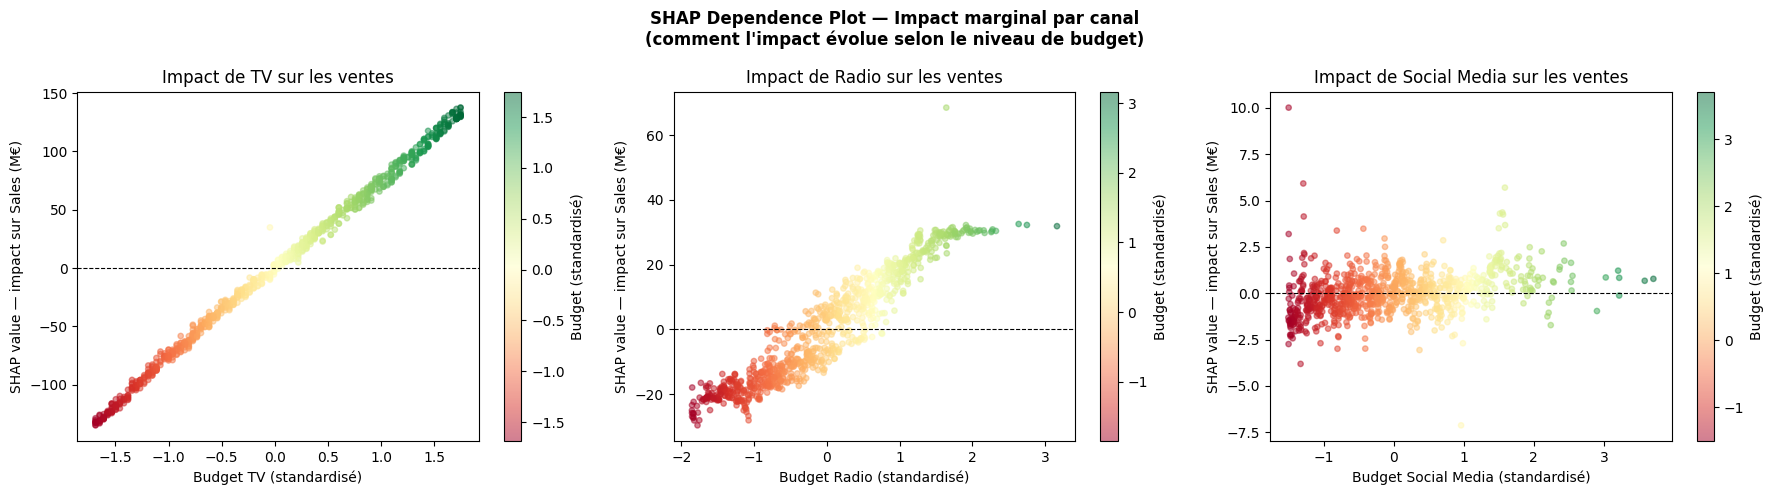

Sauvegardé → shap_dependence.png ✅


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
canaux = ['TV', 'Radio', 'Social Media']

for i, canal in enumerate(canaux):
    feat_idx = feature_names.index(canal)
    
    # Valeurs de la feature et SHAP values correspondantes
    x_vals = X_test[:, feat_idx]
    y_vals = shap_values[:, feat_idx]
    
    scatter = axes[i].scatter(
        x_vals, y_vals,
        c=x_vals, cmap='RdYlGn',
        alpha=0.5, s=15
    )
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    axes[i].set_xlabel(f'Budget {canal} (standardisé)')
    axes[i].set_ylabel(f'SHAP value — impact sur Sales (M€)')
    axes[i].set_title(f'Impact de {canal} sur les ventes')
    plt.colorbar(scatter, ax=axes[i], label='Budget (standardisé)')

plt.suptitle('SHAP Dependence Plot — Impact marginal par canal\n'
             '(comment l\'impact évolue selon le niveau de budget)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'shap_output' / 'shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()
print('Sauvegardé → shap_dependence.png ✅')

## 6. Explication locale — Waterfall Plot

Explique **une prédiction précise** :
pourquoi le modèle a prédit X M€ de ventes pour cette campagne ?

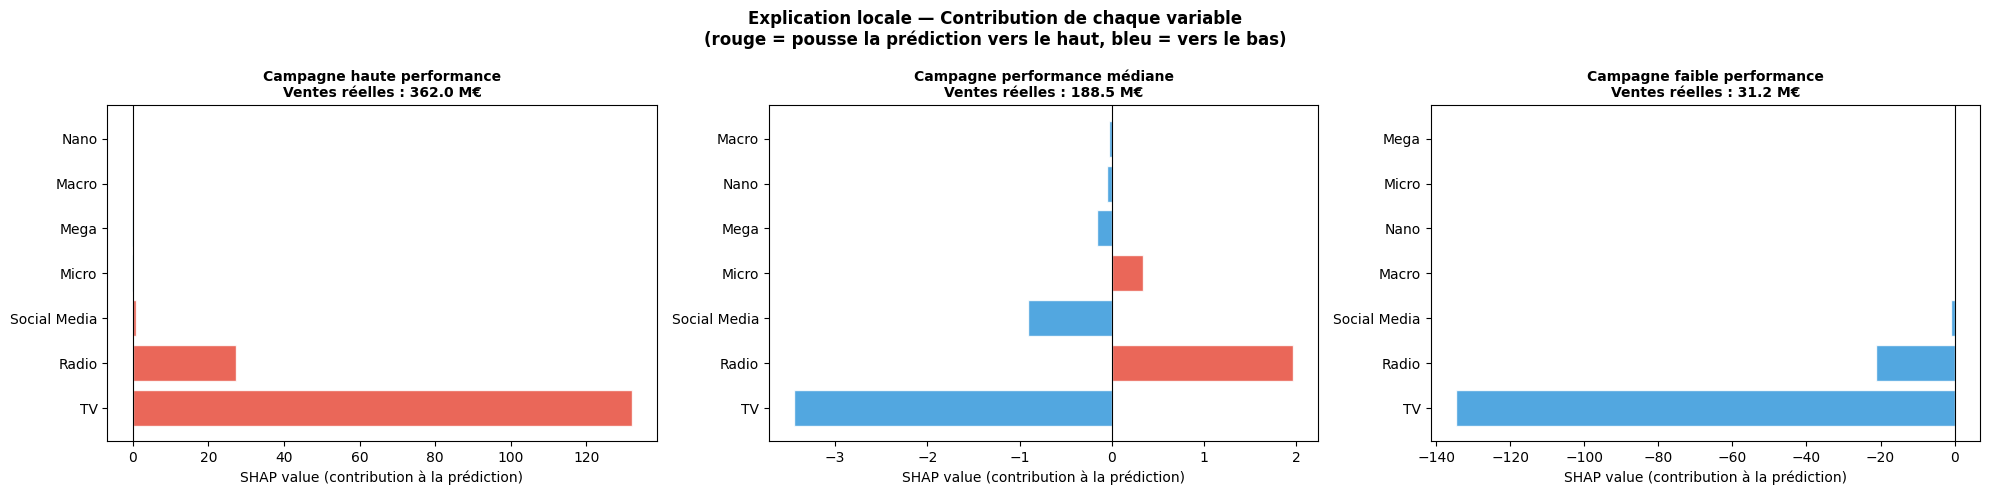

Sauvegardé → shap_local.png ✅


In [30]:
# On choisit 3 exemples intéressants :
# - la campagne avec les ventes réelles les plus élevées
# - la campagne avec les ventes réelles les plus basses
# - une campagne médiane

idx_high   = np.argmax(y_test[:len(shap_values)])
idx_low    = np.argmin(y_test[:len(shap_values)])
idx_median = np.argsort(y_test[:len(shap_values)])[len(shap_values)//2]

examples = [
    (idx_high,   'Campagne haute performance'),
    (idx_median, 'Campagne performance médiane'),
    (idx_low,    'Campagne faible performance'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (idx, title) in zip(axes, examples):
    shap_vals_i = shap_values[idx]
    base_value  = explainer.expected_value if hasattr(explainer, 'expected_value') else np.mean(y_test)
    if isinstance(base_value, np.ndarray):
        base_value = float(base_value[0])

    # Tri par valeur absolue
    sorted_idx = np.argsort(np.abs(shap_vals_i))[::-1]
    sorted_names = [feature_names[j] for j in sorted_idx]
    sorted_vals  = shap_vals_i[sorted_idx]
    colors_bar   = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_vals]

    ax.barh(sorted_names, sorted_vals, color=colors_bar, edgecolor='white', alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'{title}\nVentes réelles : {y_test[idx]:.1f} M€', fontsize=10, fontweight='bold')
    ax.set_xlabel('SHAP value (contribution à la prédiction)')

plt.suptitle('Explication locale — Contribution de chaque variable\n'
             '(rouge = pousse la prédiction vers le haut, bleu = vers le bas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(root_dir / 'shap_output' / 'shap_local.png', bbox_inches='tight', dpi=150)
plt.show()
print('Sauvegardé → shap_local.png ✅')

## 7. Synthèse — Conclusions pour le rapport

In [31]:
print('=' * 55)
print('SYNTHÈSE SHAP — CONCLUSIONS MÉTIER')
print('=' * 55)
print()

print('Importance globale des variables (ordre décroissant) :')
for rank, (name, val) in enumerate(
    shap_importance.sort_values(ascending=False).items(), 1
):
    print(f'  {rank}. {name:15s} → impact moyen de {val:.2f} M€ sur les ventes')

print()
print('Questions métier répondues :')
top_canal = shap_importance.sort_values(ascending=False).index[0]
print(f'  → Canal le plus influent    : {top_canal}')
print(f'  → Rendement marginal        : voir shap_dependence.png')
print(f'  → Explication par campagne  : voir shap_local.png')
print()
print('Fichiers générés :')
print('  shap_beeswarm.png       ← vision globale détaillée')
print('  shap_importance_bar.png ← importance moyenne par variable')
print('  shap_dependence.png     ← impact marginal visuel par canal')
print('  shap_local.png          ← explication de 3 campagnes précises')
print()
print('🚀 Prêt pour le dashboard !')

SYNTHÈSE SHAP — CONCLUSIONS MÉTIER

Importance globale des variables (ordre décroissant) :
  1. TV              → impact moyen de 64.19 M€ sur les ventes
  2. Radio           → impact moyen de 14.52 M€ sur les ventes
  3. Social Media    → impact moyen de 0.84 M€ sur les ventes
  4. Macro           → impact moyen de 0.21 M€ sur les ventes
  5. Nano            → impact moyen de 0.15 M€ sur les ventes
  6. Mega            → impact moyen de 0.14 M€ sur les ventes
  7. Micro           → impact moyen de 0.14 M€ sur les ventes

Questions métier répondues :
  → Canal le plus influent    : TV
  → Rendement marginal        : voir shap_dependence.png
  → Explication par campagne  : voir shap_local.png

Fichiers générés :
  shap_beeswarm.png       ← vision globale détaillée
  shap_importance_bar.png ← importance moyenne par variable
  shap_dependence.png     ← impact marginal visuel par canal
  shap_local.png          ← explication de 3 campagnes précises

🚀 Prêt pour le dashboard !
